## Figure 1a,b
This notebook runs off of the results of previously run models. 

It shows the significance calculations for model significance based on cross-validation.

It also runs the significance tests for differences in model performance. 

It plots these in the based on the results of 10 repetitions of 10-fold cross-validation. 

In [124]:
import numpy as np 
import pandas as pd

In [125]:
def significance_test(result1, result2, tries=10_000, random_state=41):
    """Significance test for difference between two models"""
    benchmark = np.abs(result1.mean() - result2.mean())  # observed difference
    if random_state is not None:
        np.random.seed(random_state)  # fixing seed for reproducability
    samples = np.zeros(tries)  # the distribution of differences
    for i in range(tries):
        msk = np.random.random(size=result1.shape[0]) < 0.5


        result1_perm = result1.copy()
        result2_perm = result2.copy()

        result1_perm[msk] = result2[msk]
        result2_perm[msk] = result1[msk]
        samples[i]=np.abs(result1_perm.mean()-result2_perm.mean())
    pvalue = (np.sum(samples >= benchmark) + 1) / (tries + 1)
    return pvalue

In [126]:
### calculate model significance and load cross-validation results from finished runs
import re
import glob
def get_r_p(folder):
    print(folder)
    files=glob.glob(f'{folder}*cpm_results.csv')
    files.sort()
    if len(files)!=1000:
        print(f'still running {len(files)}/1000 permutations done')
        return None
    else:
        r_vals=[]
        for i,j in enumerate(files):
            df=pd.read_csv(j)
            r_vals.append(df.mean())
            if i==0:
                obs=df
    r_vals=pd.DataFrame(r_vals)
    ref=r_vals.loc[0]
    print(len(r_vals))
    ### p-value for permutation runs 
    p_vals=(r_vals>=ref).sum()/len(r_vals)
    out=pd.DataFrame({'r':ref,'p':p_vals}).T
    return out,obs

### clean names and spaces for plotting
def clean_groups(groups):
    cleaned = {}
    for key, items in groups.items():
        new_list = []
        for item in items:
            # Split on "&", strip whitespace, remove + / -
            tokens = [re.sub(r'[+-]\s*', '', t).strip() for t in item.split("&")]
            # Remove duplicates but keep order
            unique = []
            for t in tokens:
                if t not in unique:
                    unique.append(t)
            # Rejoin
            unique = ["CD" if "Dist" in i else i for i in unique]
            new_list.append("+".join(unique))
        cleaned[key] = new_list
    return cleaned

### convert p values to categoricals for heatmap plotting
def p_to_cat(p):
    if pd.isna(p): 
        return 0      # treat NaN as non-significant
    if p <= 0.001:
        return 3
    if p <= 0.01:
        return 2
    if p <= 0.05:
        return 1
    return 0


### Load the results of the unimodal models

In [127]:
## get the pvals of the  unimultimodal models
dist_rp,dist_rvalsXfold=get_r_p('./data/results/Reading_SES_DistanceCentroid_cpm_analysis/')
FCS_rp,FC_rvalsXfold=get_r_p('./data/results/Reading_SES_FC_cpm_analysis/')
SA_rp,SA_rvalsXfold=get_r_p('./data/results/Reading_SES_SurfaceArea_cpm_analysis/')

dist_obs=pd.DataFrame(dist_rvalsXfold[['positive_top','negative_top','joint_top']])
fc_obs=pd.DataFrame(FC_rvalsXfold[['positive_top','negative_top','joint_top']])
sa_obs=pd.DataFrame(SA_rvalsXfold[['positive_top','negative_top','joint_top']])

dist_obs.rename(columns={'positive_top': 'Dist +','negative_top':'Dist -','joint_top':'Dist + & Dist -'},inplace=True)
fc_obs.rename(columns={'positive_top': 'FC +','negative_top':'FC -','joint_top':'FC + & FC -'},inplace=True)
sa_obs.rename(columns={'positive_top': 'SA +','negative_top':'SA -','joint_top':'SA + & SA -'},inplace=True)

dist_p=pd.DataFrame(dist_rp[['positive_top','negative_top','joint_top']].loc['p']).T
fc_p=pd.DataFrame(FCS_rp[['positive_top','negative_top','joint_top']].loc['p']).T
sa_p=pd.DataFrame(SA_rp[['positive_top','negative_top','joint_top']].loc['p']).T
dist_p.rename(columns={'positive_top': 'Dist +','negative_top':'Dist -','joint_top':'Dist + & Dist -'},inplace=True)
fc_p.rename(columns={'positive_top': 'FC +','negative_top':'FC -','joint_top':'FC + & FC -'},inplace=True)
sa_p.rename(columns={'positive_top': 'SA +','negative_top':'SA -','joint_top':'SA + & SA -'},inplace=True)
p_df=pd.concat([dist_p,fc_p,sa_p],axis=1)


./data/results/Reading_SES_DistanceCentroid_cpm_analysis/
1000
./data/results/Reading_SES_FC_cpm_analysis/
1000
./data/results/Reading_SES_SurfaceArea_cpm_analysis/
1000


## Get the p-values for the multimodal models

In [128]:

mm_files=!ls data/results/multiModalResults/
mm_dir='./data/results/multiModalResults/'
mm_obs=pd.read_csv(f'{mm_dir}/{mm_files[0]}',index_col=0)
mm_obs.reset_index(drop=True, inplace=True)

mm_perms={}
for i in mm_files:
    mm_perms[i]=pd.read_csv(f'{mm_dir}/{i}',index_col=0).mean()
mm_perms=pd.DataFrame(mm_perms).T
mm_perms.reset_index(drop=True, inplace=True)

obs = mm_perms.iloc[0]               # observed values (vector, one per modality)
perms = mm_perms.iloc[1:]            # permutation values

#### apply same p-value logic to 
pvals = (1 + np.sum(perms >= obs)) / (perms.shape[0] + 1)
pvals = pd.DataFrame(pvals, columns=["p"]).T

p_df=pd.concat([p_df,pvals],axis=1)

## Correct fot FDR

In [129]:
from statsmodels.stats.multitest import multipletests
p_df.loc['p']=multipletests(p_df.loc['p'],method='fdr_bh')[1]

# Table S1
## Put all the cross validation real observations together
100 values ie 10 repetitions of 10-fold cv

In [130]:
all_results=pd.concat([dist_obs,fc_obs,sa_obs,mm_obs],axis=1)

new_order=['SA +','Dist +','FC +','SA -','Dist -','FC -','SA + & SA -',
           'Dist + & Dist -','FC + & FC -','Dist + & Dist - & SA + & SA -',
          'FC + & FC - & SA + & SA -', 'FC + & FC - & Dist + & Dist -','FC + & FC - & Dist + & Dist - & SA + & SA -']

all_results=all_results[new_order]
obs=pd.DataFrame(pd.concat([sa_obs,dist_obs,fc_obs,mm_obs],axis=1)[new_order].mean()).T
p=p_df[new_order]
tables1=pd.concat([obs,p])
tables1.rename(index={0:'r'},inplace=True)
tables1

,SA +,Dist +,FC +,SA -,Dist -,FC -,SA + & SA -,Dist + & Dist -,FC + & FC -,Dist + & Dist - & SA + & SA -,FC + & FC - & SA + & SA -,FC + & FC - & Dist + & Dist -,FC + & FC - & Dist + & Dist - & SA + & SA -
r,0.132155,0.105971,0.102507,0.079512,0.131934,0.08592,0.13238,0.148200,0.177493,0.16156,0.192310,0.216521,0.215221
p,0.013000,0.029250,0.014300,0.093000,0.014300,0.02925,0.01430,0.008667,0.006500,0.00780,0.004333,0.004333,0.004333


## Plotting

## Fig. 1a

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import squareform
from collections import Counter
import matplotlib.patches as mpatches
import matplotlib as mpl
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
mpl.rcParams['pdf.fonttype'] = 42   # keep fonts editable in Illustrator
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [132]:
def compare_models(result_df,corr='bonferroni'):
    models = list(result_df.keys())
    
    # 1) Compute each unique pair once
    pair_names = []
    pvals = []
    for a, b in combinations(models, 2):
        x = result_df[a].ravel()
        y = result_df[b].ravel()
        p = significance_test(x, y)          # your function
        pair_names.append((a, b))
        pvals.append(p)
    
    # 2) Multiple-comparisons correction (Bonferroni) on the unique tests
    rej, pvals_corrected, _, _ = multipletests(pvals, method=corr)

    square_p=squareform(pvals_corrected,)
    np.fill_diagonal(square_p, 1)
    square_p=pd.DataFrame(square_p,columns=models,index=models)

    return pair_names,pvals_corrected,square_p



In [133]:
## plotting utility
def _is_alternating_plusminus(s):
    """utility func for plotting"""
    # filter to only '+' and '-' characters
    seq = [c for c in s if c in ['+', '-']]
    if len(seq) < 4:                 # require length 4+ to consider "alternating" (tunable)
        return False
    # check strict alternation
    return all(seq[i] != seq[i+1] for i in range(len(seq)-1))

In [134]:
rename_cols = {'SA + & SA -':'SA',
             'Dist + & Dist -':'CD',
             'FC + & FC -':'FC',
             'Dist + & Dist - & SA + & SA -':'CD+SA',
             'FC + & FC - & SA + & SA -':'FC+SA',
             'FC + & FC - & Dist + & Dist -':'FC+CD',
             'FC + & FC - & Dist + & Dist - & SA + & SA -':'FC+CD+SA'}

In [135]:
pairs,p_vals,square_p=compare_models(all_results)

In [136]:
import os
odir='./data/results/figure1'
os.makedirs(odir,exist_ok=True)

In [137]:
model_groups={'Positive':['SA +','Dist +','FC +'],
             'Negative':['SA -','Dist -','FC -'],
             'Joint':['SA + & SA -','Dist + & Dist -','FC + & FC -'],
             'Joint Multimodal':['Dist + & Dist - & SA + & SA -','FC + & FC - & SA + & SA -',
                           'FC + & FC - & Dist + & Dist -','FC + & FC - & Dist + & Dist - & SA + & SA -']}


In [138]:
from statannotations.Annotator import Annotator

## Plotting

In [139]:
def plot_performance_pairwise(result_df, model_group_list, figure_size, file_path, pvals):

    # --- Data reshape ----------------------------------------------------
    fold_result = result_df
    model_groups_legends = clean_groups(model_group_list)

    df_list = []
    for grp in model_groups:
        df = fold_result[model_groups[grp]].copy()
        df = df.melt(var_name="measure", value_name="Pearson r")
        df["Model"] = grp
        df_list.append(df)

    multi_df = pd.concat(df_list, ignore_index=True)
    multi_df["hue"] = multi_df["Model"] + "_" + multi_df["measure"]

    # --- Palette construction -------------------------------------------
    unique_hues = multi_df["hue"].unique()
    palette_map = {}

    groups = [
        ("Positive", "Reds"),
        ("Negative", "Blues"),
        ("Joint", "Purples"),
        ("Joint Multimodal", "Greens"),
    ]

    for grp, palname in groups:
        members = [h for h in unique_hues if h.startswith(grp + "_")]
        if not members:
            continue

        if palname.lower() == "purples":
            cmap = plt.cm.Purples
            vals = np.linspace(0.45, 0.95, len(members))
            colors = [tuple(cmap(v)) for v in vals]
        else:
            colors = sns.color_palette(palname, n_colors=len(members))

        palette_map.update(dict(zip(members, colors)))

    multi_grp = multi_df.groupby("Model")
    grp_order = ["Positive", "Negative", "Joint", "Joint Multimodal"]

    grp_p_vals = {}
    for p_grp in grp_order:
        df_tmp = multi_grp.get_group(p_grp)
        model_sets = df_tmp["measure"].unique()
        pair_names = [(a, b) for a, b in combinations(model_sets, 2)]
        grp_p_vals[p_grp] = [(pair, pvals[pair]) for pair in pair_names]

    # --- Proportional subplot sizing ------------------------------------
    sizes = [multi_grp.get_group(g)["measure"].nunique() for g in grp_order]
    widths = [s / sum(sizes) for s in sizes]

    # --- Figure layout ---------------------------------------------------
    fig = plt.figure(figsize=figure_size)
    gs = fig.add_gridspec(1, 4, width_ratios=widths, wspace=0.25)
    axes = [fig.add_subplot(gs[i]) for i in range(4)]

    # --- Shared y-axis limits & styling ---------------------------------
    ymin = multi_df["Pearson r"].min()
    ymax = multi_df["Pearson r"].max()

    for i, grp in enumerate(grp_order):
        df = multi_grp.get_group(grp)

        sns.boxplot(
            data=df, x="measure", y="Pearson r", hue="hue",
            palette=palette_map, linewidth=0.8, saturation=0.9, ax=axes[i],)
        sns.pointplot(
            data=df, x="measure", y="Pearson r", color="k",
            markers="+", linestyles="", errorbar=None, ax=axes[i]
        )

        mini_pairs = [item[0] for item in grp_p_vals[grp]]
        mini_p = [item[1] for item in grp_p_vals[grp]]
        order = list(df["measure"].unique())
        annot = Annotator(axes[i], mini_pairs, data=df, x="measure", y="Pearson r", order=order)
        annot.configure(test=None, text_format="star", hide_non_significant=True, loc="inside", line_offset=0, line_height=0, text_offset=0.2, use_fixed_offset=True)
        annot.set_pvalues_and_annotate([float(p) for p in mini_p])

        axes[i].get_legend().remove()
        axes[i].set_xlabel(""); axes[i].set_ylabel("")
        axes[i].set_title("")
        axes[i].set_ylim(ymin - 0.025, ymax + 0.02)
        axes[i].set_xticks([])
        axes[i].tick_params(axis="x", labelbottom=False, length=0)

        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)
        axes[i].spines["left"].set_visible(False)
        axes[i].spines["bottom"].set_color("#5a5a5a")
        axes[i].spines["bottom"].set_linewidth(0.7)

        axes[i].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
        axes[i].tick_params(axis="y", labelsize=7, length=0)

        if i == 0:
            axes[i].tick_params(axis="y", labelleft=True, labelsize=7, length=0)
        else:
            axes[i].set_yticklabels([])
            axes[i].tick_params(axis="y", labelleft=False, left=False)

    plt.tight_layout()
    plt.savefig(f"{file_path}.png", dpi=600, bbox_inches="tight", transparent=True)
    plt.savefig(f"{file_path}.svg", bbox_inches="tight", transparent=True)

    return fig, axes

We start with a bad but useful plot that we can use to make sure we get the stats right for the actual figure. 
We can plot all the pairwise 

In [140]:
p_dict=dict(zip(pairs,p_vals))
model_sig_p={}
for i in p_df:
    model_sig_p[(i,i)]=p_df[i].values[0]

The below plot replicates Fig. 1a
You will notice that Fig. 1a looks nicer. 
That's because we recreated the lines in illustrator. 
Also note that all pariwise comparisons are shown in the heatmap (Fig. 1b)
We only show within model type here. 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SA + vs. FC +: Custom statistical test, P_val:1.560e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SA - vs. Dist -: Custom statistical test, P_val:7.799e-03
Dist - vs. FC -: Custom statistical test, P_val:1.560e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SA + & SA - vs. FC + & FC -: Custom statistical test, P_val:2.340e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 

/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/1752035084.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 669x137 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

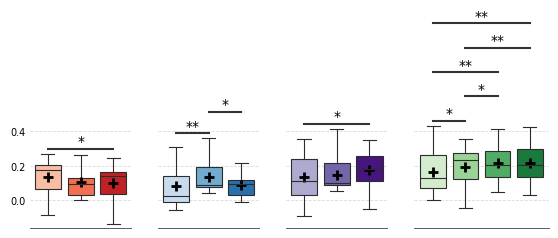

In [141]:
plot_performance_pairwise(all_results,model_groups,(6.69,1.37),f'{odir}/model_performance_pairwise_comp',p_dict,)

In [142]:
def plot_performance_model_sig(result_df, model_group_list, figure_size, file_path, pvals):

    # --- Data reshape ----------------------------------------------------
    fold_result = result_df
    model_groups_legends = clean_groups(model_group_list)

    df_list = []
    for grp in model_groups:
        df = fold_result[model_groups[grp]].copy()
        df = df.melt(var_name="measure", value_name="Pearson r")
        df["Model"] = grp
        df_list.append(df)

    multi_df = pd.concat(df_list, ignore_index=True)
    multi_df["hue"] = multi_df["Model"] + "_" + multi_df["measure"]

    # --- Palette construction -------------------------------------------
    unique_hues = multi_df["hue"].unique()
    palette_map = {}

    groups = [
        ("Positive", "Reds"),
        ("Negative", "Blues"),
        ("Joint", "Purples"),
        ("Joint Multimodal", "Greens"),
    ]

    for grp, palname in groups:
        members = [h for h in unique_hues if h.startswith(grp + "_")]
        if not members:
            continue

        if palname.lower() == "purples":
            cmap = plt.cm.Purples
            vals = np.linspace(0.45, 0.95, len(members))
            colors = [tuple(cmap(v)) for v in vals]
        else:
            colors = sns.color_palette(palname, n_colors=len(members))

        palette_map.update(dict(zip(members, colors)))

    # Merge "Joint Multimodal" into "Joint"
    multi_df.loc[multi_df["Model"] == "Joint Multimodal", "Model"] = "Joint"
    multi_grp = multi_df.groupby("Model")
    grp_order = list(multi_grp.groups.keys())[::-1]

    # --- Proportional subplot sizing ------------------------------------
    sizes = [multi_grp.get_group(g)["measure"].nunique() for g in grp_order[:3]]
    widths = [s / sum(sizes) for s in sizes]

    # --- Figure layout ---------------------------------------------------
    fig = plt.figure(figsize=figure_size)
    gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.25)
    axes = [fig.add_subplot(gs[i]) for i in range(3)]

    # --- Shared y-axis limits & styling ---------------------------------
    ymin = multi_df["Pearson r"].min()
    ymax = multi_df["Pearson r"].max()

    for i, grp in enumerate(grp_order[:3]):
        df = multi_grp.get_group(grp)

        # Main plot
        sns.boxplot(
            data=df, x="measure", y="Pearson r", hue="hue",
            palette=palette_map, linewidth=0.8, saturation=0.9, ax=axes[i],)
        sns.pointplot(
            data=df, x="measure", y="Pearson r", color="k",
            markers="+", linestyles="", errorbar=None, ax=axes[i]
        )
        mini_pairs=[i[0] for i in grp_p_vals[grp]]
        mini_p=[i[1] for i in grp_p_vals[grp]]
        print(mini_pairs)
        order = list(df["measure"].unique())
        print(order)
        mini_pairs=[(i,i) for i in order]
        mini_pvals=[pvals[i] for i in mini_pairs]
        print(mini_pvals)
        annot = Annotator(axes[i],mini_pairs, data=df, x="measure", y="Pearson r", order=order)
        annot.configure(test=None, text_format="star", hide_non_significant=True, loc="inside", line_offset=0.002, line_height=0.003, text_offset=0.2, use_fixed_offset=True)
        annot.set_pvalues_and_annotate([float(p) for p in mini_pvals])

        axes[i].get_legend().remove()

        # --- Move panel title to bottom (x-label area) -------------------
        axes[i].set_xlabel(grp, fontsize=8, labelpad=6)
        axes[i].set_title("")

        # --- Axis styling ------------------------------------------------
        axes[i].set_ylim(ymin - 0.025, ymax + 0.02)
        # axes[i].set_xticks([])

        if i > 0:  # Remove y-axis for center & right panels
            axes[i].set_ylabel("")
            axes[i].set_yticklabels([])
            axes[i].tick_params(left=False)

        # Spines
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)
        axes[i].spines["left"].set_visible(False)
        axes[i].spines["bottom"].set_color("#5a5a5a")
        axes[i].spines["bottom"].set_linewidth(0.7)
        axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)

        # Gridlines
        axes[i].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)

        # Tick appearance
        axes[i].tick_params(axis="y", labelsize=7, length=0)
        axes[i].tick_params(axis="x", length=0)

        axes[i].set_xticks([]);
        axes[i].tick_params(labelbottom=False, labelleft=False)
        # for s in axes[i].spines.values(): s.set_visible(False)
        
        # REMOVE X AND Y LABELS COMPLETELY
        axes[i].set_xlabel(""); axes[i].set_ylabel("")
        axes[i].set_xticks([])
        axes[i].tick_params(axis="x", labelbottom=False, length=0)
        
        if i == 0:
            # LEFTMOST panel: show numeric y-tick values (optional axis title kept separately)
            axes[i].tick_params(axis="y", labelleft=True, labelsize=7, length=0)
        else:
            # middle & right: remove y labels and ticks
            axes[i].set_ylabel("")
            axes[i].set_yticklabels([])
            axes[i].tick_params(axis="y", labelleft=False, left=False)
        

    # --- Final layout & save --------------------------------------------
    plt.tight_layout()
    # fig.savefig(f"{file_path}.pdf", bbox_inches="tight")
    plt.savefig(f"{file_path}.png", dpi=600, bbox_inches="tight",transparent=True)
    plt.savefig(f"{file_path}.svg", bbox_inches="tight",transparent=True)

    # return fig, axes


In [143]:
#### Function does box plots witho or without starts for significance
def plot_performance_model(result_df, model_group_list, figure_size, file_path, pvals,stars=False):
    # --- accept either a dict-like mapping or the original name ----------------
    model_groups = model_group_list  # expected: mapping group_name -> list-of-column-names
    # --- Data reshape ----------------------------------------------------
    fold_result = result_df
    model_groups_legends = clean_groups(model_group_list)

    df_list = []
    for grp in model_groups:
        df = fold_result[model_groups[grp]].copy()
        df = df.melt(var_name="measure", value_name="Pearson r")
        df["Model"] = grp
        df_list.append(df)

    multi_df = pd.concat(df_list, ignore_index=True)
    multi_df["hue"] = multi_df["Model"] + "_" + multi_df["measure"]

    # --- Palette construction -------------------------------------------
    unique_hues = multi_df["hue"].unique()
    palette_map = {}

    groups = [
        ("Positive", "Reds"),
        ("Negative", "Blues"),
        ("Joint", "Purples"),
        ("Joint Multimodal", "Greens"),
    ]
    for grp, palname in groups:
        members = [h for h in unique_hues if h.startswith(grp + "_")]
        if not members:
            continue

        if palname.lower() == "purples":
            cmap = plt.cm.Purples
            vals = np.linspace(0.45, 0.95, len(members))
            colors = [tuple(cmap(v)) for v in vals]
        else:
            colors = sns.color_palette(palname, n_colors=len(members))

        palette_map.update(dict(zip(members, colors)))

    # --- DO NOT merge "Joint Multimodal" into "Joint" anymore ----------------
    # (previous code changed Model values; we leave them separate now)

    multi_grp = multi_df.groupby("Model")
    grp_order = list(multi_grp.groups.keys())[::-1]  # reverse if you want that visual order
    mm=grp_order.pop(2)
    grp_order.append(mm)
    
    # --- Proportional subplot sizing (for up to 4 groups) --------------------
    n_panels = min(4, len(grp_order))  # ensure we only create as many panels as there are groups (up to 4)
    selected_groups = grp_order[:n_panels]
    sizes = [multi_grp.get_group(g)["measure"].nunique() for g in selected_groups]
    widths = [s / sum(sizes) for s in sizes]

    # --- Figure layout ---------------------------------------------------
    fig = plt.figure(figsize=figure_size)
    gs = fig.add_gridspec(1, n_panels, width_ratios=widths, wspace=0.25)
    axes = [fig.add_subplot(gs[i]) for i in range(n_panels)]

    # --- Shared y-axis limits & styling ---------------------------------
    ymin = multi_df["Pearson r"].min()
    ymax = multi_df["Pearson r"].max()

    for i, grp in enumerate(selected_groups):
        df = multi_grp.get_group(grp)

        # Main plot
        sns.boxplot(
            data=df, x="measure", y="Pearson r", hue="hue",
            palette=palette_map, linewidth=0.8, saturation=0.9, ax=axes[i],
        )
        sns.pointplot(
            data=df, x="measure", y="Pearson r", color="k",
            markers="+", linestyles="", errorbar=None, ax=axes[i]
        )
        
        order = list(df["measure"].unique())

        if stars:
            mini_pairs = [(m, m) for m in order]
            mini_pvals = [pvals[i] for i in mini_pairs]
            annot = Annotator(axes[i],mini_pairs, data=df, x="measure", y="Pearson r", order=order)
            annot.configure(test=None, text_format="star", hide_non_significant=True, loc="inside", line_offset=0.002, line_height=0.003, text_offset=0.2, use_fixed_offset=True)
            annot.set_pvalues_and_annotate([float(p) for p in mini_pvals])

        # remove legend per-panel
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()

        # --- Move panel title to bottom (x-label area) -------------------
        axes[i].set_xlabel(grp, fontsize=8, labelpad=6)
        axes[i].set_title("")

        # --- Axis styling ------------------------------------------------
        axes[i].set_ylim(ymin - 0.025, ymax + 0.02)

        if i > 0:  # Remove y-axis for center/right panels
            axes[i].set_ylabel("")
            axes[i].set_yticklabels([])
            axes[i].tick_params(left=False)

        # Spines
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)
        axes[i].spines["left"].set_visible(False)
        axes[i].spines["bottom"].set_color("#5a5a5a")
        axes[i].spines["bottom"].set_linewidth(0.7)
        axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)

        # Gridlines
        axes[i].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)

        # Tick appearance
        axes[i].tick_params(axis="y", labelsize=7, length=0)
        axes[i].tick_params(axis="x", length=0)

        # Remove axis labels/ticks as before
        axes[i].set_xlabel(""); axes[i].set_ylabel("")
        axes[i].set_xticks([])
        axes[i].tick_params(axis="x", labelbottom=False, length=0)

        if i == 0:
            # LEFTMOST panel: show numeric y-tick values (optional axis title kept separately)
            axes[i].tick_params(axis="y", labelleft=True, labelsize=7, length=0)
        else:
            # other panels: hide y labels and ticks
            axes[i].set_ylabel("")
            axes[i].set_yticklabels([])
            axes[i].tick_params(axis="y", labelleft=False, left=False)

    # --- Final layout & save --------------------------------------------
    plt.tight_layout()
    plt.savefig(f"{file_path}.png", dpi=600, bbox_inches="tight", transparent=True)
    plt.savefig(f"{file_path}.svg", bbox_inches="tight", transparent=True)

    return fig, axes


For the figure we used the following plot and remade the lines. 

/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)
/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)
/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)
/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)
/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:1

(<Figure size 570x180 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

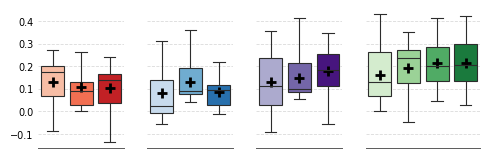

In [144]:
plot_performance_model(all_results,model_groups,(5.7,1.8),f'{odir}/schaefer400_multimodal_performance',model_sig_p,stars=False)

The next plot is equivalent to table S1

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SA + vs. SA +: Custom statistical test, P_val:1.300e-02
Dist + vs. Dist +: Custom statistical test, P_val:2.925e-02
FC + vs. FC +: Custom statistical test, P_val:1.430e-02


/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Dist - vs. Dist -: Custom statistical test, P_val:1.430e-02
FC - vs. FC -: Custom statistical test, P_val:2.925e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SA + & SA - vs. SA + & SA -: Custom statistical test, P_val:1.430e-02


/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)


Dist + & Dist - vs. Dist + & Dist -: Custom statistical test, P_val:8.667e-03
FC + & FC - vs. FC + & FC -: Custom statistical test, P_val:6.500e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Dist + & Dist - & SA + & SA - vs. Dist + & Dist - & SA + & SA -: Custom statistical test, P_val:7.800e-03


/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)


FC + & FC - & SA + & SA - vs. FC + & FC - & SA + & SA -: Custom statistical test, P_val:4.333e-03
FC + & FC - & Dist + & Dist - vs. FC + & FC - & Dist + & Dist -: Custom statistical test, P_val:4.333e-03
FC + & FC - & Dist + & Dist - & SA + & SA - vs. FC + & FC - & Dist + & Dist - & SA + & SA -: Custom statistical test, P_val:4.333e-03


/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:110: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(order, rotation=90, ha="center", fontsize=7)
/var/folders/zw/p_y6jjzx6fj3p8wxssbmj1pw0000gn/T/ipykernel_77295/2062982219.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 570x180 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

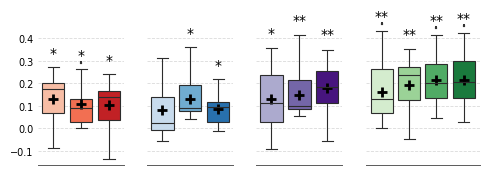

In [145]:
plot_performance_model(all_results,model_groups,(5.7,1.8),f'{odir}/schaefer400_multimodal_performance_w_stars',model_sig_p,stars=True)

# Fig. 1b
### Plot pairwise absolute model difference and significance 


In [146]:

cols = all_results.columns
abs_diff_mat = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        abs_diff_mat.loc[i, j] = all_results[i].mean() - all_results[j].mean()
corr_matrix=np.abs(abs_diff_mat)

In [147]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

In [148]:
square_p_cat = square_p.applymap(p_to_cat) ### shift to categorical 

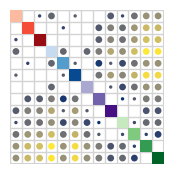

In [149]:
fig, ax = plt.subplots(figsize=(2,2))
ax.set_facecolor('white')
ax.imshow(np.ones_like(corr_matrix), cmap='gray_r', interpolation='nearest',alpha=1)

# ax.imshow(np.abs(corr_matrix), cmap='gray_r', interpolation='nearest',alpha=0.1)
labels=list(corr_matrix.columns)
# set the tick labels and rotation for the x and y axes
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

# shift ticks of x axis to top of the graph
ax.tick_params(axis='x', which='both', labelbottom=False, labeltop=True, bottom=False, top=True, length=0)

# format ticks
# ax.set_yticklabels(labels, fontsize=7, color = "orange", fontweight = "bold")
# ax.set_xticklabels(labels, fontsize=7, color = "orange", fontweight = "bold")

ax.set_yticklabels("" )
ax.set_xticklabels("")


# # minor ticks (for grid lines ONLY)
ax.set_xticks(np.arange(len(labels)+1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(labels)+1) - 0.5, minor=True)


# draw grid on minor ticks
ax.grid(which="minor", color="lightgray", linestyle="solid", linewidth=0.5)


ax.grid(which="minor", color="lightgray", linestyle="solid", linewidth=1, )

ax.tick_params(which='major', length=0)
ax.tick_params(which='minor', length=0)


# add rectangle around the grid
rect = plt.Rectangle((-.5, -.5), len(corr_matrix.columns), len(corr_matrix.columns), linewidth=1.5, edgecolor='lightgray', facecolor='none')
ax.add_patch(rect)

# create circles with radius proportional to the absolute value of correlation
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        correlation = corr_matrix.iat[i, j]
        pval_rad=square_p_cat.iat[i, j]
        norm = plt.Normalize(0, np.max(corr_matrix))  # specify the range of values for the colormap
        sm = plt.cm.ScalarMappable(norm=norm, cmap='cividis')
        color = sm.to_rgba(correlation)
        circle = Circle((i, j), radius=pval_rad/7, facecolor=color)
        ax.add_patch(circle)
for spine in ax.spines.values(): 
    spine.set_visible(False)

# --- diagonal coloring logic (adapted from your heatmap function) ---
# classify labels into types IN ORDER
label_types = []
for lab in labels:
    s = str(lab)
    n_plus = s.count('+')
    n_minus = s.count('-')
    if n_plus > 0 and n_minus == 0:
        label_types.append('plus_only')
    elif n_minus > 0 and n_plus == 0:
        label_types.append('minus_only')
    elif n_plus > 0 and n_minus > 0:
        if _is_alternating_plusminus(s):
            label_types.append('alternating')
        else:
            label_types.append('both')
    else:
        label_types.append(None)

# Count how many of each type we have
type_counts = Counter([t for t in label_types if t is not None])

# Colormap functions for types
type_cmaps = {
    'plus_only': plt.cm.Reds,
    'minus_only': plt.cm.Blues,
    'both': plt.cm.Purples,
    'alternating': plt.cm.Greens
}

# Sampling ranges per type (format: (low, high) in [0..1] for cmap sampling)
type_ranges = {
    'plus_only': (0.25, 0.9),      # reds: light -> dark
    'minus_only': (0.25, 0.9),     # blues: light -> dark
    'both': (0.45, 0.95),          # purples: darker start
    'alternating': (0.25, 0.9)     # greens
}

# prepare sampled shades for each type
type_shades = {}
for t, cnt in type_counts.items():
    cmap_fn = type_cmaps[t]
    low, high = type_ranges.get(t, (0.25, 0.9))
    if cnt == 1:
        samples = cmap_fn(0.6)[np.newaxis, :]
    else:
        samples = cmap_fn(np.linspace(low, high, cnt))
    type_shades[t] = samples

# assign shades in the order labels appear
type_cursor = {t: 0 for t in type_counts}
diagonal_colors = []
for t in label_types:
    if t is None:
        diagonal_colors.append(None)
    else:
        shade = type_shades[t][type_cursor[t]]
        type_cursor[t] += 1
        diagonal_colors.append(shade)

# --- draw diagonal filled rectangles (one per i==j) ---
for i, color in enumerate(diagonal_colors):
    if color is None:
        continue
    # rectangle coordinates: cell i spans (i-0.5, i-0.5) .. (i+0.5, i+0.5)
    rect = mpatches.Rectangle((i - 0.5, i - 0.5), 1, 1,
                              transform=ax.transData,
                              facecolor=tuple(color),
                              edgecolor='none',
                              alpha=1.0,
                              zorder=3)
    ax.add_patch(rect)
plt.savefig(f"{odir}/circle_heatmap.png", dpi=600, bbox_inches="tight",transparent=True)
plt.savefig(f"{odir}/circle_heatmap.svg", bbox_inches="tight",transparent=True)

plt.show()

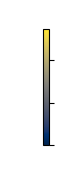

In [150]:
fig2, ax2 = plt.subplots(figsize=(0.5, 2))

norm = mcolors.Normalize(vmin=0, vmax=np.max(corr_matrix))
c_scale = plt.cm.ScalarMappable(norm=norm, cmap='cividis')

cbar = plt.colorbar(c_scale, ax=ax2, orientation="vertical")

# keep ticks, remove labels
cbar.set_ticklabels([])

ax2.axis("off")

plt.savefig(f"{odir}/circle_colorbar.png", dpi=600, bbox_inches="tight", transparent=True)
